In [50]:
import os
import json

import numpy as np
import pandas as pd
import h5py
import cupy as cp
from tqdm import tqdm
import torch
from PIL import Image
import matplotlib.pyplot as plt

In [37]:
FILE = os.path.join("..", "data", "dataset.csv")

In [38]:
df = pd.read_csv(FILE)
df.head()

,index,depth,file,result,hash,img_width,img_height,n_two_qubit_gates,n_one_qubit_gates,amount_gates,file_size_bytes,n_barriers
0,0,12,./data/images/0.png,"[0.13470552733900498, 0.3430160187667615, -0.0...",7bcc57e8d8092c45b29b73a766aad4d9,727,290,3,33,"{""z"": 8, ""id"": 3, ""ry"": 6, ""x"": 10, ""h"": 6, ""s...",16736,0
1,2,2,./data/images/2.png,"[1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...",8daae35df88469234f61091a1c9b9955,196,290,2,1,"{""cx"": 1, ""swap"": 1, ""id"": 1}",5953,0
2,1,5,./data/images/1.png,"[0.06291308288755482, 0.0, 0.0, 0.0, 0.0629130...",1aba9ebc404442b06955c7dc2008f55e,340,290,2,7,"{""x"": 3, ""ry"": 2, ""swap"": 1, ""cx"": 1, ""h"": 1, ...",9186,0
3,5,15,./data/images/5.png,"[0.0, 0.0, -0.006753529957809293, 0.0, 0.0, 0....",748034d9fe397dfd7d9565a16c8fab89,823,290,8,19,"{""x"": 5, ""id"": 2, ""ry"": 4, ""h"": 6, ""z"": 2, ""cx...",17470,0
4,3,22,./data/images/3.png,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.327...",b9d363b25c65bef554d179db2e183de5,1258,290,20,15,"{""ry"": 3, ""z"": 4, ""id"": 2, ""h"": 4, ""x"": 2, ""sw...",25500,0


In [39]:
print("Prior: ", len(df))
no_duplicated_hash = df.drop_duplicates(subset="hash")
print("No Duplicated hash: ", len(no_duplicated_hash))
no_duplicated_files_as_well = no_duplicated_hash.drop_duplicates(subset="file")
print("No Duplicated Files: ", len(no_duplicated_files_as_well))

df = no_duplicated_files_as_well

Prior:  100000
No Duplicated hash:  98445
No Duplicated Files:  98445


In [40]:
## Fix amplitudes to probabilities
## this part of the code is only for a tiny modification that I forgot to do in the code to extract the probabilities instead of amplitudes.

df["result"] = df["result"]\
                    .apply(json.loads)\
                    .apply(lambda x : (np.array(x,dtype=np.float32)**2).tolist())\
                    .apply(json.dumps)
df["result"].head()

0    [0.01814557984471321, 0.11765999346971512, 0.0...
1    [1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...
2    [0.003958055749535561, 0.0, 0.0, 0.0, 0.003958...
3    [0.0, 0.0, 4.5610166125698015e-05, 0.0, 0.0, 0...
4    [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.107...
Name: result, dtype: object

In [41]:
## [::-1] for little endian
df["class"] = df["result"]\
                .apply(json.loads)\
                .apply(lambda x: np.array(x, dtype=np.float32))\
                .apply(lambda arr: (arr > 0).astype(np.uint8))\
                .astype(str)\
                .apply(lambda x: str(x).replace("[","").replace("]","").replace(" ", "")[::-1])\
                .apply(lambda x: int(x,2))
df.head()

,index,depth,file,result,hash,img_width,img_height,n_two_qubit_gates,n_one_qubit_gates,amount_gates,file_size_bytes,n_barriers,class
0,0,12,./data/images/0.png,"[0.01814557984471321, 0.11765999346971512, 0.0...",7bcc57e8d8092c45b29b73a766aad4d9,727,290,3,33,"{""z"": 8, ""id"": 3, ""ry"": 6, ""x"": 10, ""h"": 6, ""s...",16736,0,4294967295
1,2,2,./data/images/2.png,"[1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...",8daae35df88469234f61091a1c9b9955,196,290,2,1,"{""cx"": 1, ""swap"": 1, ""id"": 1}",5953,0,1
2,1,5,./data/images/1.png,"[0.003958055749535561, 0.0, 0.0, 0.0, 0.003958...",1aba9ebc404442b06955c7dc2008f55e,340,290,2,7,"{""x"": 3, ""ry"": 2, ""swap"": 1, ""cx"": 1, ""h"": 1, ...",9186,0,571548177
3,5,15,./data/images/5.png,"[0.0, 0.0, 4.5610166125698015e-05, 0.0, 0.0, 0...",748034d9fe397dfd7d9565a16c8fab89,823,290,8,19,"{""x"": 5, ""id"": 2, ""ry"": 4, ""h"": 6, ""z"": 2, ""cx...",17470,0,17039620
4,3,22,./data/images/3.png,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.107...",b9d363b25c65bef554d179db2e183de5,1258,290,20,15,"{""ry"": 3, ""z"": 4, ""id"": 2, ""h"": 4, ""x"": 2, ""sw...",25500,0,2852148480


In [42]:
print("Total unique classes: ", len(df["class"].unique()))

Total unique classes:  2097


In [43]:
df['index'] = range(len(df))
assert len(df["index"].unique()) == len(df)

In [44]:
print("Saving clean df...")
df.to_csv(os.path.join("..", "data", "clean_dataset.csv"), index=False)

Saving clean df...


In [58]:
## 2dwt using Haar
N_THREADS = 1024
kernel = r"""
extern "C"{
    __global__ void dtw2_borders(
                    const unsigned int* input,
                    unsigned char* out,
                    unsigned int quadrant_width,
                    unsigned int img_width,
                    unsigned int max_pixels_quadrant,
                    unsigned int max_pixels_image
    ){
        unsigned int global_index = (blockIdx.x * blockDim.x) + threadIdx.x;
        if(global_index >= max_pixels_quadrant)
            return;

        unsigned int width_index = global_index % quadrant_width;
        unsigned int height_index = global_index / quadrant_width;

        unsigned int original_img_w_index = width_index * 2;
        unsigned int original_img_h_index = height_index * 2;

        unsigned int curr_input_index = (original_img_h_index * img_width) + original_img_w_index;
        unsigned int curr_input_index_row = ((original_img_h_index+1) * img_width) + original_img_w_index;

        float current_pixel  = curr_input_index >= max_pixels_image ? 1.0 : input[curr_input_index];
        float next_col_pixel = (curr_input_index+1) >= max_pixels_image ? 1.0 : input[curr_input_index+1];
        float next_row_pixel = curr_input_index_row >= max_pixels_image ? 1.0 : input[curr_input_index_row];
        float diag_pixel     = (curr_input_index_row+1) >= max_pixels_image ? 1.0 : input[curr_input_index_row+1];

        float B_val = 0.5 * (current_pixel - next_col_pixel + next_row_pixel - diag_pixel);
        float C_val = 0.5 * (current_pixel + next_col_pixel - next_row_pixel - diag_pixel);
        float sum = abs(B_val + C_val);

        out[(height_index * quadrant_width) + width_index] = (unsigned char) (sum > 0.5 ? 1 : 0);
    }
};
"""

In [46]:
def transform_image(img:Image) -> torch.Tensor:
    """
    Transform and normalize a PIL image into a torch tensor ranging values from 0 to 1.
    """

    img = img.convert("L")
    width,height = img.size
    quadrant_w, quadrant_h = int(np.ceil(width/2)), int(np.ceil(height/2))

    dtw2 = cp.RawKernel(kernel, "dtw2_borders")        

    gpu_img = cp.asarray(img,dtype=cp.uint32)
    out = cp.zeros((quadrant_h, quadrant_w), dtype=cp.uint8)

    n_blocks = int(np.ceil((quadrant_h*quadrant_w)/N_THREADS))
    dtw2((n_blocks,), (N_THREADS,), (gpu_img, out, quadrant_w, width, quadrant_h*quadrant_w, width*height))
    cp.cuda.runtime.deviceSynchronize()

    return torch.tensor(out.get())

In [48]:
MAX_IMAGES_PER_H5_FILE = 10_000
counter = 0
with tqdm(desc="Processing Files", total=len(df)) as progress:
    current_h5_file_index = 0
    current_h5_file_path = os.path.join("..", "data", f"images_{current_h5_file_index}.hdf5")
    file = h5py.File(current_h5_file_path, "a")
        
    for i,data in df[["index", "file"]].iterrows():
        df_file = os.path.join("..", str(data["file"]))
        img_index = int(data["index"])
        progress.set_description(f"processing file: {df_file}")
        
        with Image.open(df_file) as img:
            tensor = transform_image(img)
            file.create_dataset(f"{img_index}", data=tensor)
            df.loc[i,"h5_file"] = current_h5_file_path
            progress.update(1)

        if counter > 0 and counter % MAX_IMAGES_PER_H5_FILE == 0:
            current_h5_file_index += 1
            current_h5_file_path = os.path.join("..", "data", f"images_{current_h5_file_index}.hdf5")
            print("switching to h5 file: ", current_h5_file_path)
            file.close()
            file = h5py.File(current_h5_file_path, "a")

        counter += 1
    file.close()

processing file: .././data/images/10086.png:  10%|███▎                            | 10011/98445 [03:15<26:40, 55.25it/s]

switching to h5 file:  ../data/images_1.hdf5


processing file: .././data/images/20229.png:  20%|██████▌                         | 20008/98445 [06:41<25:46, 50.72it/s]

switching to h5 file:  ../data/images_2.hdf5


processing file: .././data/images/30360.png:  30%|█████████▊                      | 30010/98445 [09:55<16:14, 70.25it/s]

...

processing file: .././data/images/81214.png:  81%|██████████████████████████      | 80009/98445 [27:14<06:12, 49.45it/s]

switching to h5 file:  ../data/images_8.hdf5


processing file: .././data/images/91394.png:  91%|█████████████████████████████▎  | 90007/98445 [30:43<03:09, 44.62it/s]

switching to h5 file:  ../data/images_9.hdf5


processing file: .././data/images/99999.png: 100%|████████████████████████████████| 98445/98445 [33:38<00:00, 48.78it/s]


In [49]:
classes_split = df[["index", "result", "class", "h5_file"]]
print("Saving classes...")
classes_split.to_csv(os.path.join("..", "data", "circuit_outputs.csv"), index=False)

Saving classes...


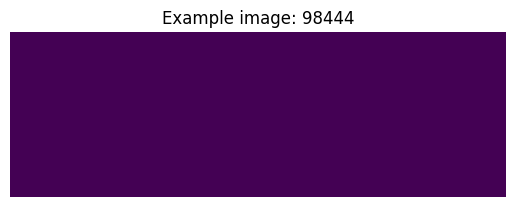

In [54]:
with h5py.File(os.path.join("..", "data", "images_9.hdf5"), "r") as file:
    selected_key = list(file.keys())[-1]
    
    plt.imshow(file[selected_key])
    plt.axis('off')
    plt.title(f"Example image: {selected_key}")
    plt.show()